# Journee du 30/05/2008

In [2]:
#Package graphe

using Pkg

cd(@__DIR__)
Pkg.activate("../")
using Dates, SonifSismo, CairoMakie

  Activating project at `~/Downloads/sonifSismo.jl-main`


In [ ]:
Pkg.add(url="https://github.com/tp2750/TuningSystems.jl") # si le package son ne marche pas

In [3]:
#Package son

using Pkg

cd(@__DIR__)
Pkg.activate("../")


using Dates
using SonifSismo
using Statistics
using WAV
using Seis
using CairoMakie
using DSP: conv
using TuningSystems
using Test
push!(LOAD_PATH, "Home/djangohulot/Downloads/sonifSismo.jl/TuningSystems.jl-main/TuningSystems.jl-main/src")

  Activating project at `~/Downloads/sonifSismo.jl-main`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "Home/djangohulot/Downloads/soni" ⋯ 26 bytes ⋯ "-main/TuningSystems.jl-main/src"

In [4]:
archive = DataArchive("/home/djangohulot/Downloads/mtFujiContinuous")

DataArchive("/home/djangohulot/Downloads/mtFujiContinuous", "/home/djangohulot/Downloads/mtFujiContinuous/mseed", "/home/djangohulot/Downloads/mtFujiContinuous/catalog/h2008", :JST, Hour(9))

In [5]:
stations = available_stations(archive)

11-element Vector{String}:
 "FJO"
 "FJO1"
 "FJZ"
 "FUJ"
 "HSO"
 "MMS"
 "MMS2"
 "MTS"
 "MTS2"
 "OIS"
 "SBSR"

In [6]:
available_channels(archive)

33-element Vector{ChannelAvailability}:
 ChannelAvailability("EV", "FJO", "", "E", [Date("2008-05-25"), Date("2008-05-26"), Date("2008-05-27"), Date("2008-05-28"), Date("2008-05-29"), Date("2008-05-30"), Date("2008-05-31")], ["/home/djangohulot/Downloads/mtFujiContinuous/mseed/2008/05/25/EV.FJO..E.20080525.mseed", "/home/djangohulot/Downloads/mtFujiContinuous/mseed/2008/05/26/EV.FJO..E.20080526.mseed", "/home/djangohulot/Downloads/mtFujiContinuous/mseed/2008/05/27/EV.FJO..E.20080527.mseed", "/home/djangohulot/Downloads/mtFujiContinuous/mseed/2008/05/28/EV.FJO..E.20080528.mseed", "/home/djangohulot/Downloads/mtFujiContinuous/mseed/2008/05/29/EV.FJO..E.20080529.mseed", "/home/djangohulot/Downloads/mtFujiContinuous/mseed/2008/05/30/EV.FJO..E.20080530.mseed", "/home/djangohulot/Downloads/mtFujiContinuous/mseed/2008/05/31/EV.FJO..E.20080531.mseed"])
 ChannelAvailability("EV", "FJO", "", "N", [Date("2008-05-25"), Date("2008-05-26"), Date("2008-05-27"), Date("2008-05-28"), Date("2008-05-29"),

In [7]:
include("/home/djangohulot/Downloads/sonifSismo.jl-main/examples/sonify_one_trace.jl")

false

# convolution du seisme a differentes directions wE, wN, wU

In [115]:
start_time = DateTime(2008, 5, 30,0,0,0) - Hour(9)  # conversion hour JST to UTC
end_time   = DateTime(2008, 5, 30, 23,59,59)  - Hour(9)   # UTC

traces30wE = read_window(
    archive,
    start_time,
    end_time;
    stations="FUJ",
    channels=["wE"],
    merge=true,
 #    merge_gaps=:zero,       # or :linear
    processed=true,
    bandpass=( 0.01, 3),
)

#event
events30 = read_catalog(
    archive;
    start=start_time,
    stop=end_time
)

271-element Vector{JMAEvent}:
 JMAEvent('J', DateTime("2008-05-30T00:00:49.270"), DateTime("2008-05-29T15:00:49.270"), 36.075833333333335, 142.007, 69.0, 2.9, "V", 1, "FAR E OFF IBARAKI PREF", "J2008053000004927 026 360455 062 1420042 145 69     29V   521   3112FAR E OFF IBARAKI PREF   30K")
 JMAEvent('J', DateTime("2008-05-30T00:02:35.150"), DateTime("2008-05-29T15:02:35.150"), 44.02483333333333, 141.722, 10.49, 0.0, "V", 1, "RUMOI REGION", "J2008053000023515 030 440149 076 1414332 112 104918100V   511   1  2RUMOI REGION              9K")
 JMAEvent('J', DateTime("2008-05-30T00:06:36.810"), DateTime("2008-05-29T15:06:36.810"), 42.0575, 142.24583333333334, 54.02, 0.3, "V", 1, "S OFF URAKAWA", "J2008053000063681 031 420345 129 1421475 127 540237403V   511   1 30S OFF URAKAWA            17K")
 JMAEvent('J', DateTime("2008-05-30T00:19:17.260"), DateTime("2008-05-29T15:19:17.260"), 34.83883333333333, 137.95333333333335, 16.26, 0.9, "V", 1, "SW SHIZUOKA PREF", "J2008053000191726 008 345033 0

In [66]:
start_time = DateTime(2008, 5, 30,0,0,0) - Hour(9)  # conversion hour JST to UTC
end_time   = DateTime(2008, 5, 30, 23,59,59)  - Hour(9)   # UTC

traces30wN = read_window(
    archive,
    start_time,
    end_time;
    stations="FUJ",
    channels=["wN"],
    merge=true,
 #    merge_gaps=:zero,       # or :linear
    processed=true,
    bandpass=(3.01, 6),
)

#event
events30 = read_catalog(
    archive;
    start=start_time,
    stop=end_time
)

271-element Vector{JMAEvent}:
 JMAEvent('J', DateTime("2008-05-30T00:00:49.270"), DateTime("2008-05-29T15:00:49.270"), 36.075833333333335, 142.007, 69.0, 2.9, "V", 1, "FAR E OFF IBARAKI PREF", "J2008053000004927 026 360455 062 1420042 145 69     29V   521   3112FAR E OFF IBARAKI PREF   30K")
 JMAEvent('J', DateTime("2008-05-30T00:02:35.150"), DateTime("2008-05-29T15:02:35.150"), 44.02483333333333, 141.722, 10.49, 0.0, "V", 1, "RUMOI REGION", "J2008053000023515 030 440149 076 1414332 112 104918100V   511   1  2RUMOI REGION              9K")
 JMAEvent('J', DateTime("2008-05-30T00:06:36.810"), DateTime("2008-05-29T15:06:36.810"), 42.0575, 142.24583333333334, 54.02, 0.3, "V", 1, "S OFF URAKAWA", "J2008053000063681 031 420345 129 1421475 127 540237403V   511   1 30S OFF URAKAWA            17K")
 JMAEvent('J', DateTime("2008-05-30T00:19:17.260"), DateTime("2008-05-29T15:19:17.260"), 34.83883333333333, 137.95333333333335, 16.26, 0.9, "V", 1, "SW SHIZUOKA PREF", "J2008053000191726 008 345033 0

In [67]:
start_time = DateTime(2008, 5, 30,0,0,0) - Hour(9)  # conversion hour JST to UTC
end_time   = DateTime(2008, 5, 30, 23,59,59)  - Hour(9)   # UTC

traces30wU = read_window(
    archive,
    start_time,
    end_time;
    stations="FUJ",
    channels=["wU"],
    merge=true,
 #    merge_gaps=:zero,       # or :linear
    processed=true,
    bandpass=(6.01, 9),
)

#event
events30 = read_catalog(
    archive;
    start=start_time,
    stop=end_time
)

271-element Vector{JMAEvent}:
 JMAEvent('J', DateTime("2008-05-30T00:00:49.270"), DateTime("2008-05-29T15:00:49.270"), 36.075833333333335, 142.007, 69.0, 2.9, "V", 1, "FAR E OFF IBARAKI PREF", "J2008053000004927 026 360455 062 1420042 145 69     29V   521   3112FAR E OFF IBARAKI PREF   30K")
 JMAEvent('J', DateTime("2008-05-30T00:02:35.150"), DateTime("2008-05-29T15:02:35.150"), 44.02483333333333, 141.722, 10.49, 0.0, "V", 1, "RUMOI REGION", "J2008053000023515 030 440149 076 1414332 112 104918100V   511   1  2RUMOI REGION              9K")
 JMAEvent('J', DateTime("2008-05-30T00:06:36.810"), DateTime("2008-05-29T15:06:36.810"), 42.0575, 142.24583333333334, 54.02, 0.3, "V", 1, "S OFF URAKAWA", "J2008053000063681 031 420345 129 1421475 127 540237403V   511   1 30S OFF URAKAWA            17K")
 JMAEvent('J', DateTime("2008-05-30T00:19:17.260"), DateTime("2008-05-29T15:19:17.260"), 34.83883333333333, 137.95333333333335, 16.26, 0.9, "V", 1, "SW SHIZUOKA PREF", "J2008053000191726 008 345033 0

In [43]:
#DONNES POUR LA ZONE
lat_max = 35.45
lon_max = 138.85
lat_min = 35.25
lon_min = 135.65

135.65

In [88]:
plot_events30 = read_catalog(
    archive;
    start = start_time ,
    stop = end_time ,
    predicate =events30 ->
        !ismissing(events30.latitude) && 
        !ismissing(events30.longitude) && 
        lat_min <= events30.latitude <= lat_max && 
        lon_min <= events30.longitude <= lon_max
)

JMAEvent[]

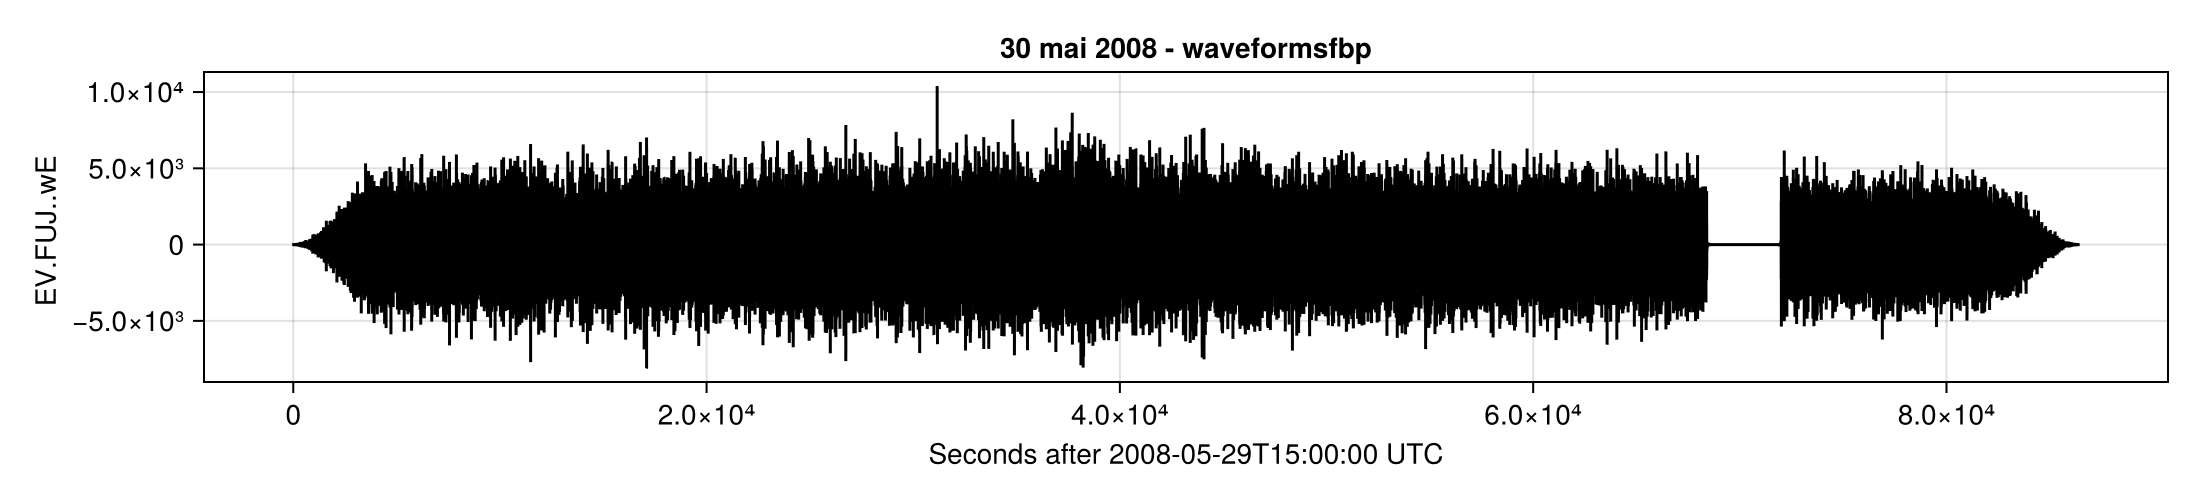

In [89]:
#plot wave forms with events

wavefig2 = plot_waveforms(
    traces30wE; #signal sismique
    events=plot_events30, #evennemennts sismiques (LFE, EQ)
    title = "30 mai 2008 - waveformsfbp"
)


In [36]:
Mi = play(s.(t.(n.("E"))))
save_wav("30_mai_2008/audio/E.wav", sound(t.(n.("E"))))

In [61]:
Sol = play(s.(t.(n.("G"))))
save_wav("30_mai_2008/audio/G.wav", sound(t.(n.("G"))))

In [95]:
Do = play(s.(t.(n.("C"))))
save_wav("30_mai_2008/audio/C.wav", sound(t.(n.("C"))))

In [96]:
Do_grave = play(s.(t.(n.("C2"))))
save_wav("30_mai_2008/audio/C2.wav", sound(t.(n.("C2"))))

In [26]:
accord_parfait = play(s(t.([1, 5/4, 3/2] .* 440)), bpm=30, file="c-major-just.wav")
save("30_mai_2008/audio/accord_parfait_c-major-just", accord_parfait)

ErrorException: No applicable_savers found for UNKNOWN

In [114]:
audiowE = sonify_trace(
    traces30wE[1], #take the first event from the waveform plot
    acceleration = 1000,
    harmonics = (100, 500), #harmoniques à 100Hz et 500Hz
    level = 0.92,
    gain=7,
    saturation=:soft
)


audiowE = convolve_with_audio(audiowE, "/home/djangohulot/Downloads/sonifSismo.jl-main/notebooks/30_mai_2008/audio/C.wav" ; kernel_seconds=2, mix=0.5)

write_sonification("30_mai_2008/audio/event30wE.wav", audiowE)

"30_mai_2008/audio/event30wE.wav"

In [83]:
audiowN = sonify_trace(
    traces30wN[1], #take the first event from the waveform plot
    acceleration = 1000,
    harmonics = (100, 500),
    gain=5,
    saturation=:soft
)

audiowN = convolve_with_audio(audiowN, "/home/djangohulot/Downloads/sonifSismo.jl-main/notebooks/30_mai_2008/audio/E.wav" ; kernel_seconds=2, mix=0.5)
write_sonification("30_mai_2008/audio/event30wN.wav", audiowN)

"30_mai_2008/audio/event30wN.wav"

In [93]:
audiowU = sonify_trace(
    traces30wU[1], #take the first event from the waveform plot
    acceleration = 1000,
    harmonics = (100, 500),
    gain=5,
    saturation=:soft
)
audiowU = convolve_with_audio(audiowU, "/home/djangohulot/Downloads/sonifSismo.jl-main/notebooks/30_mai_2008/audio/G.wav" ; kernel_seconds=2, mix=0.5)

write_sonification("30_mai_2008/audio/event30wU.wav", audiowU)

"30_mai_2008/audio/event30wU.wav"

In [ ]:
# Combiner les trois signaux en les additionnant
combined_signal = (audiowE.signal .+ audiowN.signal .+ audiowU.signal) ./ 3

combined_rendered = (
    signal = combined_signal,
    sample_rate = audiowE.sample_rate,
    audio_duration = length(combined_signal) / audiowE.sample_rate,
    seismic_duration = auDo = play(s.(t.(n.("C"))))
save_wav("30_mai_2008/audio/C.wav", sound(t.(n.("C"))))diowE.seismic_duration
)

write_sonification("30_mai_2008/audio/combined_event30.wav", combined_rendered)

"30_mai_2008/audio/combined_event30.wav"

In [83]:
#plot wave forms with events

wavefig2 = plot_waveforms(
    traces30; #signal sismique
    events=plot_events30, #evennemennts sismiques (LFE, EQ)
    title = "30 mai 2008 - waveformsfbp"
)


UndefVarError: UndefVarError: `_Hours_after` not defined in `SonifSismoMakieExt`
Suggestion: check for spelling errors or missing imports.

In [116]:
audio = sonify_trace(
    traces30[1], #take the first event from the waveform plot
    acceleration = 1000,
    harmonics = (100, 131),
    gain=4,
    saturation=:soft
)


write_sonification("30_mai_2008/audio/event30sansbp.wav", audio)

"30_mai_2008/audio/event30sansbp.wav"

# De 00h a 4h

In [69]:
start_time = DateTime(2008, 5, 30,0,0,0) - Hour(9)  # conversion hour JST to UTC
end_time   = DateTime(2008, 5, 30, 4,0,0)  - Hour(9)   # UTC

traces12 = read_window(
    archive,
    start_time,
    end_time;
    stations="FUJ",
    channels=["wE", "wN", "wU"],
    merge=true,
 #    merge_gaps=:zero,       # or :linear
    processed=true,
    bandpass=(10, 15),
)

#event
event12 = read_catalog(
    archive;
    start=start_time,
    stop=end_time
)

40-element Vector{JMAEvent}:
 JMAEvent('J', DateTime("2008-05-30T00:00:49.270"), DateTime("2008-05-29T15:00:49.270"), 36.075833333333335, 142.007, 69.0, 2.9, "V", 1, "FAR E OFF IBARAKI PREF", "J2008053000004927 026 360455 062 1420042 145 69     29V   521   3112FAR E OFF IBARAKI PREF   30K")
 JMAEvent('J', DateTime("2008-05-30T00:02:35.150"), DateTime("2008-05-29T15:02:35.150"), 44.02483333333333, 141.722, 10.49, 0.0, "V", 1, "RUMOI REGION", "J2008053000023515 030 440149 076 1414332 112 104918100V   511   1  2RUMOI REGION              9K")
 JMAEvent('J', DateTime("2008-05-30T00:06:36.810"), DateTime("2008-05-29T15:06:36.810"), 42.0575, 142.24583333333334, 54.02, 0.3, "V", 1, "S OFF URAKAWA", "J2008053000063681 031 420345 129 1421475 127 540237403V   511   1 30S OFF URAKAWA            17K")
 JMAEvent('J', DateTime("2008-05-30T00:19:17.260"), DateTime("2008-05-29T15:19:17.260"), 34.83883333333333, 137.95333333333335, 16.26, 0.9, "V", 1, "SW SHIZUOKA PREF", "J2008053000191726 008 345033 02

In [70]:
plot_events = read_catalog(
    archive;
    start = start_time ,
    stop = end_time ,
    predicate =events12 ->
        !ismissing(events12.latitude) && 
        !ismissing(events12.longitude) && 
        lat_min <= events12.latitude <= lat_max && 
        lon_min <= events12.longitude <= lon_max
)

JMAEvent[]

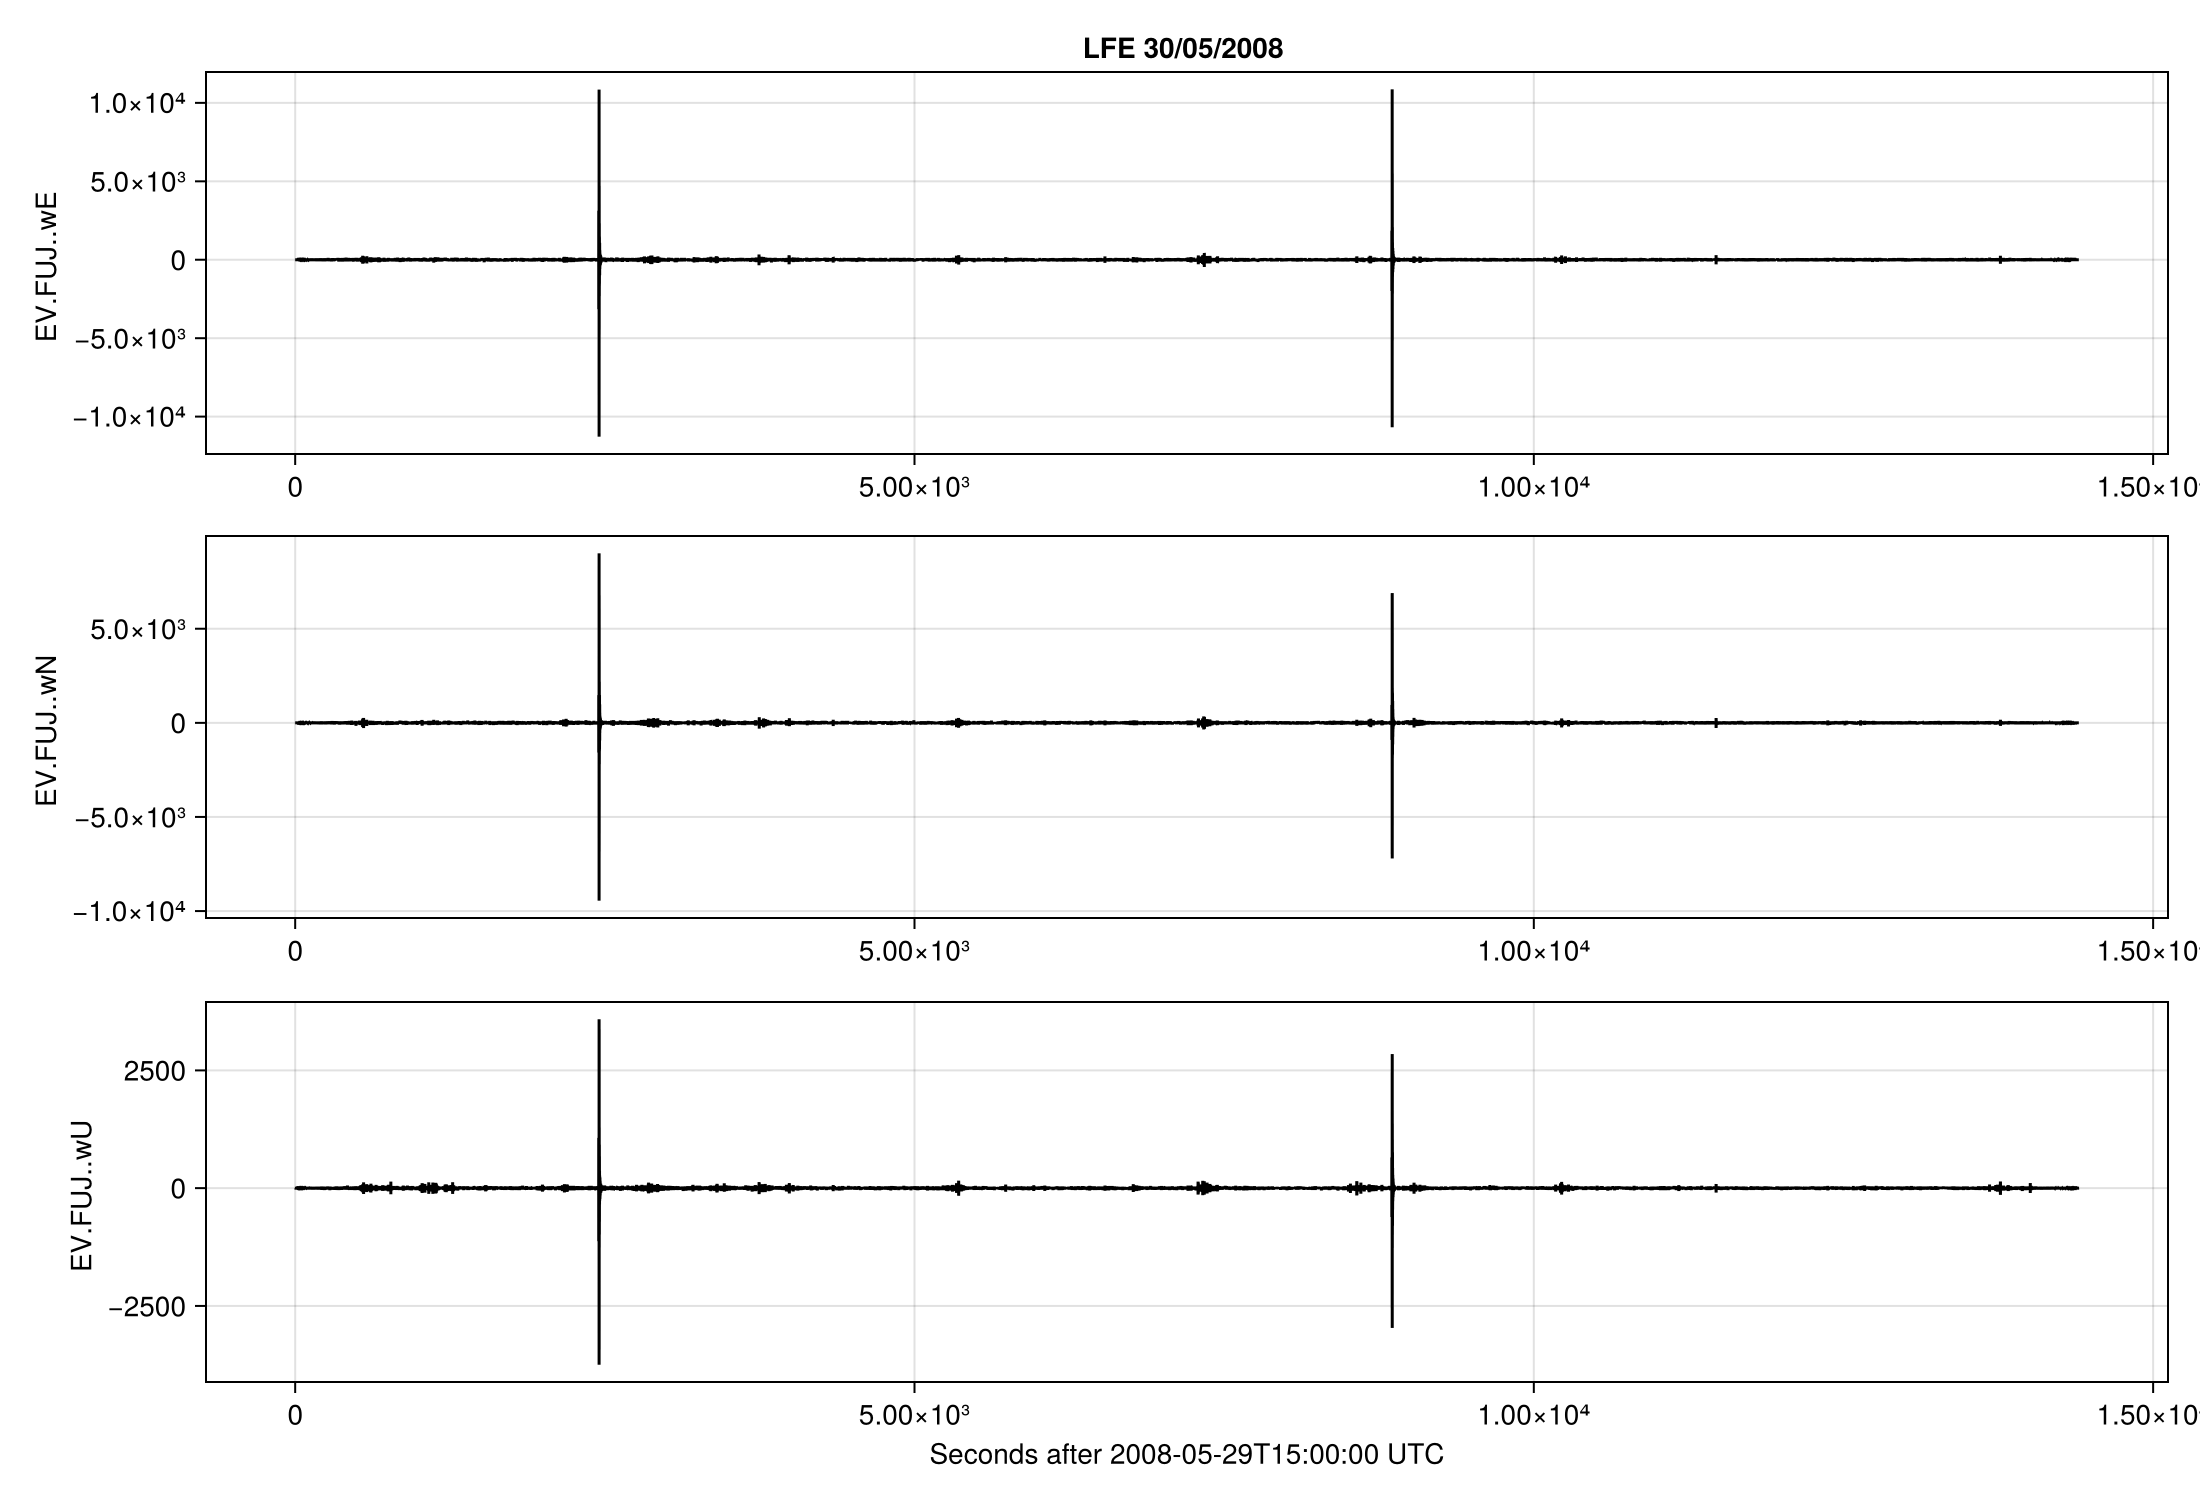

In [71]:
#plot wave forms with events

wavefig2 = plot_waveforms(
    traces12; #signal sismique
    events=plot_events12, #evennemennts sismiques (LFE, EQ)
    title = "LFE 30/05/2008 "
)

In [41]:
wavefig2_frequency = plot_time_frequency(
    traces12;
    events=plot_events12,
    window=2.0,
    overlap=0.75,
    title="30 mai 2008 - frequency",
)

save("image/30 mai 2008 - frequency.png", wavefig2_frequency)

In [73]:
audio = sonify_trace(
    traces12[1], #take the first event from the waveform plot
    acceleration = 120,
    harmonics = (400, 500),
    gain=3,
    saturation=:soft
)

write_sonification("30_mai_2008/audio/event12hbp.wav", audio)

"30_mai_2008/audio/event12hbp.wav"

# De 8h a 12h

In [29]:
start_time = DateTime(2008, 5, 30,8,0,0) - Hour(9)  # conversion hour JST to UTC
end_time   = DateTime(2008, 5, 30, 12,0,0)  - Hour(9)   # UTC

traces812 = read_window(
    archive,
    start_time,
    end_time;
    stations="FUJ",
    channels=["wE", "wN", "wU"],
    merge=true,
 #    merge_gaps=:zero,       # or :linear
    processed=true,
    bandpass=(10, 15),
)

#event
event812 = read_catalog(
    archive;
    start=start_time,
    stop=end_time
)

38-element Vector{JMAEvent}:
 JMAEvent('J', DateTime("2008-05-30T08:06:37.840"), DateTime("2008-05-29T23:06:37.840"), 38.228833333333334, 141.76483333333334, 53.06, 1.5, "V", 1, "E OFF MIYAGI PREF", "J2008053008063784 008 381373 023 1414589 039 530604615V   511   2 65E OFF MIYAGI PREF        27K")
 JMAEvent('J', DateTime("2008-05-30T08:09:21.900"), DateTime("2008-05-29T23:09:21.900"), 38.94316666666667, 142.59266666666667, 30.29, 1.5, "V", 1, "E OFF MIYAGI PREF", "J2008053008092190 014 385659 032 1423556 065 302922015V   511   2 65E OFF MIYAGI PREF        23K")
 JMAEvent('J', DateTime("2008-05-30T08:11:52.120"), DateTime("2008-05-29T23:11:52.120"), 34.69833333333333, 133.70116666666667, 21.38, 0.7, "V", 1, "OKAYAMA PREF", "J2008053008115212 006 344190 018 1334207 016 213805807V   511   6229OKAYAMA PREF              9K")
 JMAEvent('J', DateTime("2008-05-30T08:30:25.490"), DateTime("2008-05-29T23:30:25.490"), 25.27, 128.153, 73.0, 2.7, "V", 1, "NEAR OKINAWAJIMA ISLAND", "J200805300830254

In [30]:
#DONNES POUR LA ZONE
lat_max = 35.45
lon_max = 138.85
lat_min = 35.25
lon_min = 135.65
min_depth = 20
max_depth = 27
magnitude_min = 2.5
magnitude_max = 5.0

5.0

In [31]:
plot_events = read_catalog(
    archive;
    start = start_time,
    stop = end_time,
    predicate =events ->
        !ismissing(events.depth_km) && 
        !ismissing(events.longitude) &&
        !ismissing(events.latitude) &&
        !ismissing(events.magnitude) && 
        min_depth <= events.depth_km <= max_depth && 
        lon_min <= events.longitude <= lon_max &&
        magnitude_min <= events.magnitude <= magnitude_max && 
        lat_min <= events.latitude <= lat_max
)

JMAEvent[]

In [60]:
wavefig2_frequency = plot_time_frequency(
    traces812;
    events=plot_events,
    window=2.0,
    overlap=0.75,
    title="30 mai 2008 - frequency",
)

save("image/30 mai 2008 - frequency812.png", wavefig2_frequency)

In [15]:
audio = sonify_trace(
    traces812[1], #take the first event from the waveform plot
    acceleration = 500,
    harmonics = (100, 500),
    gain=3,
    saturation =:soft
)


write_sonification("30_mai_2008/audio/event812.wav", audio)

"30_mai_2008/audio/event812.wav"

In [35]:
play(s(t.([1, 5/4, 3/2] .* 440)), bpm=30, file="c-major-just.wav")

# Convolution en Do

In [19]:
audio = sonify_trace(
    traces812[1], #take the first event from the waveform plot
    acceleration = 500,
    harmonics = (100, 500),
    gain=10,
    saturation =:soft
)

convolve = convolve_with_audio(audio, "/home/djangohulot/Downloads/sonifSismo.jl-main/notebooks/c-major-just.wav" ; kernel_seconds=2, mix=0.5)


write_sonification("30_mai_2008/audio/convolution_en_Do.wav", convolve)

"30_mai_2008/audio/convolution_en_Do.wav"

# Convolution Taylor Swift

In [1]:
audio = sonify_trace(
    traces812[1], #take the first event from the waveform plot
    acceleration = 100, #acceleration = 500, EQ en meme temps que le drop
    harmonics = (100, 500),
    gain=10,
    saturation =:soft
)

taylor swif = convolve_with_audio(audio, "/home/djangohulot/Downloads/sonifSismo.jl-main/notebooks/30_mai_2008/audio/Taylor Swift - Fearless (Taylors Version) (Lyrics).wav" ; kernel_seconds=2, mix=0.5)


write_sonification("30_mai_2008/audio/convolution_Swift_Taylor.wav", taylor swif)
)

UndefVarError: UndefVarError: `traces812` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Musique test

# Interlude Star Wars

In [158]:
play(s.(t.(n.("E"), tuning=just)))
play(s.(t.(n.("E"), tuning=just)))
play(s.(t.(n.(("E")), tuning=just)))
play(s.(t.(n.(("C")), tuning=just)), bpm = 70)
play(s.(t.(n.("G"),tuning=just)), bpm = 140)
play(s.(t.(n.("E"), tuning=just)))
play(s.(t.(n.("C"), tuning=just)))
play(s.(t.(n.("G"), tuning=just)), bpm = 140)
play(s.(t.(n.("E"), tuning=just)))

# Interlude Ai se te pego

In [37]:
play(s.(t.(n.("C"))), bpm = 190)
play(s.(t.(n.("C"))), bpm = 190)
play(s.(t.(n.("C+1"))), bpm = 300)
play(s.(t.(n.("B"))), bpm = 120)
play(s.(t.(n.("B"))), bpm = 120)
play(s.(t.(n.("B"))), bpm = 120)

play(s.(t.(n.("A"))), bpm = 190)
play(s.(t.(n.("C"))), bpm = 190)
play(s.(t.(n.("A"))), bpm = 190)
play(s.(t.(n.("C"))), bpm = 150)

play(s.(t.(n.("A"))), bpm = 230)
play(s.(t.(n.("C"))), bpm = 200)
play(s.(t.(n.("A"))), bpm = 60)


play(s.(t.(n.("C"))), bpm = 90)
play(s.(t.(n.("C"))), bpm = 200)
play(s.(t.(n.("C"))), bpm = 200)
play(s.(t.(n.("B"))), bpm = 200)
play(s.(t.(n.("B"))), bpm = 200)
play(s.(t.(n.("C"))), bpm = 200)



play(s.(t.(n.("C"))), bpm = 90)
play(s.(t.(n.("C"))), bpm = 200)
play(s.(t.(n.("A"))), bpm = 200)
play(s.(t.(n.("C"))), bpm = 200)
play(s.(t.(n.("A"))), bpm = 60)


play(s.(t.(n.("C"))), bpm = 230)
play(s.(t.(n.("C"))), bpm = 230)
play(s.(t.(n.("E"))), bpm = 230)
play(s.(t.(n.("G"))), bpm = 170)


play(s.(t.(n.("B"))), bpm = 230)
play(s.(t.(n.("B"))), bpm = 230)
play(s.(t.(n.("D"))), bpm = 230)
play(s.(t.(n.("G"))), bpm = 170)


play(s.(t.(n.("A"))), bpm = 230)
play(s.(t.(n.("A"))), bpm = 230)
play(s.(t.(n.("C"))), bpm = 230)
play(s.(t.(n.("E"))), bpm = 230)
play(s.(t.(n.("C"))), bpm = 230)
play(s.(t.(n.("F"))), bpm = 230)
play(s.(t.(n.("E"))), bpm = 230)
play(s.(t.(n.("D"))), bpm = 230)
play(s.(t.(n.("C"))), bpm = 170)


play(s.(t.(n.("C"))), bpm = 230)
play(s.(t.(n.("C"))), bpm = 230)
play(s.(t.(n.("E"))), bpm = 230)
play(s.(t.(n.("G"))), bpm = 170)


play(s.(t.(n.("B"))), bpm = 230)
play(s.(t.(n.("B"))), bpm = 230)
play(s.(t.(n.("D"))), bpm = 230)
play(s.(t.(n.("G"))), bpm = 170)


play(s.(t.(n.("A"))), bpm = 230)
play(s.(t.(n.("A"))), bpm = 230)
play(s.(t.(n.("C"))), bpm = 230)
play(s.(t.(n.("E"))), bpm = 230)
play(s.(t.(n.("C"))), bpm = 230)
play(s.(t.(n.("F"))), bpm = 230)
play(s.(t.(n.("E"))), bpm = 230)
play(s.(t.(n.("D"))), bpm = 230)
play(s.(t.(n.("C"))), bpm = 170)

In [15]:
C_just = tone.(note.(split("C E G")), tuning=just)

play(s.(C_just))

In [ ]:
C_octave = pitch_class(tone.(note.(C_just, tuning = just)); base = 1)

play(s.(C_octave))

MethodError: MethodError: no method matching /(::TuningSystems.Tone, ::Int64)
The function `/` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  /(!Matched::BigInt, ::Union{Int16, Int32, Int64, Int8, UInt16, UInt32, UInt64, UInt8})
   @ Base gmp.jl:566
  /(!Matched::Graphics.Vec2, ::Real)
   @ Graphics ~/.julia/packages/Graphics/MapF4/src/Graphics.jl:112
  /(!Matched::Missing, ::Number)
   @ Base missing.jl:123
  ...
